In [2]:
import pandas as pd
import numpy as np
import windrose
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
files = list(Path("../data").rglob("*.xls*"))
print(f'No. of files: {len(files)}')

for file in files:
    print(file)

No. of files: 18
../data/2025/23MARCH25-1MAY25.xls
../data/2025/AUG 2025.xls
../data/2025/DEC 2025.xls
../data/2025/JAN 2025.xls
../data/2025/JULY 2025.xls
../data/2025/JuNE 2025.xls
../data/2025/MAY 2025.xls
../data/2025/NOV2025.xls
../data/2025/OCT 2025.xls
../data/2025/SEP 2025.xls
../data/2026/APR20-MAY42026.xls
../data/2026/August 2026.xls
../data/2026/FEB 2026.xls
../data/2026/JAN 2026.xls
../data/2026/JULY2026.xls
../data/2026/june 2026.xls
../data/2026/MARCH-APR 20.xls
../data/2026/MAY 2026.xls


In [4]:
df = pd.read_csv(files[0], sep='\t')
print(df.head())
print(df.columns)

  Date(dd/mm/yy) Time(HH:MM) W Direction(Deg)    Temp(Deg C)  \
0       24/03/25       13:57    -Menu Access-             Or   
1       24/03/25       14:00             40.0           37.5   
2       24/03/25       14:27    -Menu Access-             Or   
3       24/03/25       14:46    -Menu Access-             Or   
4       24/03/25       15:23    -Menu Access-             Or   

      R Humidity(%) Solar(CCM) B Pressure(mmHg) Spd(Km/hr) Rain(mm)  \
0  -System Restart-        NaN              NaN        NaN      NaN   
1              16.0        1.4            743.3        1.3      0.0   
2  -System Restart-        NaN              NaN        NaN      NaN   
3  -System Restart-        NaN              NaN        NaN      NaN   
4  -System Restart-        NaN              NaN        NaN      NaN   

   Unnamed: 9  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         NaN  
Index(['Date(dd/mm/yy)', 'Time(HH:MM)', 'W Direction(Deg)', 'Temp(Deg C)',
       'R Humidit

In [5]:
wind_data = []
for file in files:
    df = pd.read_csv(file, sep='\t')
    df = df[
        [
            'Date(dd/mm/yy)',
            'Time(HH:MM)',
            'W Direction(Deg)',
            'Spd(Km/hr)'
        ]
    ]
    wind_data.append(df)

windrose_data = pd.concat(wind_data)
print(windrose_data.head(20))

   Date(dd/mm/yy) Time(HH:MM) W Direction(Deg) Spd(Km/hr)
0        24/03/25       13:57    -Menu Access-        NaN
1        24/03/25       14:00             40.0        1.3
2        24/03/25       14:27    -Menu Access-        NaN
3        24/03/25       14:46    -Menu Access-        NaN
4        24/03/25       15:23    -Menu Access-        NaN
5        24/03/25       15:23    -Menu Access-        NaN
6        24/03/25       15:25    -Menu Access-        NaN
7        24/03/25       15:27    -Menu Access-        NaN
8        24/03/25       15:28    -Menu Access-        NaN
9        24/03/25       16:00            114.0        0.7
10       24/03/25       17:00             99.0        0.6
11       24/03/25       18:00            113.0        0.7
12       24/03/25       19:00            129.0        0.6
13       24/03/25       20:00            124.0        1.5
14       24/03/25       21:00            114.0        0.5
15       24/03/25       22:00            109.0        0.1
16       24/03

In [6]:
print("Total rows:", len(windrose_data))

print("\nMissing values:")
print(windrose_data.isna().sum())

print("\nNon-numeric direction values:")
print(
    windrose_data[
        pd.to_numeric(windrose_data["W Direction(Deg)"], errors="coerce").isna()
    ]["W Direction(Deg)"].value_counts()
)

Total rows: 12692

Missing values:
Date(dd/mm/yy)        0
Time(HH:MM)           0
W Direction(Deg)      0
Spd(Km/hr)          254
dtype: int64

Non-numeric direction values:
W Direction(Deg)
-Menu Access-       254
-Transfer Error-     77
Name: count, dtype: int64


In [7]:
print("\nNumeric wind statistics:")

temp = windrose_data.copy()

temp["W Direction(Deg)"] = pd.to_numeric(
    temp["W Direction(Deg)"], errors="coerce"
)

temp["Spd(Km/hr)"] = pd.to_numeric(
    temp["Spd(Km/hr)"], errors="coerce"
)

print(temp[["W Direction(Deg)", "Spd(Km/hr)"]].describe())


Numeric wind statistics:
       W Direction(Deg)    Spd(Km/hr)
count      12361.000000  12361.000000
mean         198.558943      1.577033
std          108.035843      1.751237
min            0.000000      0.000000
25%          111.000000      0.100000
50%          236.000000      0.900000
75%          286.000000      2.600000
max          377.000000     10.600000


In [8]:
windrose_data[
    pd.to_numeric(windrose_data["W Direction(Deg)"], errors="coerce") >= 360
]
windrose_data[
    pd.to_numeric(windrose_data["W Direction(Deg)"], errors="coerce") < 0
]
windrose_data[
    pd.to_numeric(windrose_data["Spd(Km/hr)"], errors="coerce") < 0
]

,Date(dd/mm/yy),Time(HH:MM),W Direction(Deg),Spd(Km/hr)


In [9]:
direction_numeric = pd.to_numeric(
    windrose_data["W Direction(Deg)"],
    errors="coerce"
)

print(direction_numeric[direction_numeric >= 360].value_counts().sort_index())

W Direction(Deg)
360.0    148
361.0      4
362.0      1
363.0      8
364.0      4
365.0      1
366.0     11
367.0      1
368.0      4
370.0      1
371.0      1
372.0      1
373.0      3
376.0      2
377.0      1
Name: count, dtype: int64


In [10]:
print(
    windrose_data.loc[
        direction_numeric >= 360,
        ["Date(dd/mm/yy)", "Time(HH:MM)", "W Direction(Deg)", "Spd(Km/hr)"]
    ]
)

    Date(dd/mm/yy) Time(HH:MM) W Direction(Deg) Spd(Km/hr)
23        25/03/25        5:00            360.0        0.1
99        28/03/25        3:00            360.0        0.0
101       28/03/25        5:00            360.0        0.0
152       30/03/25        4:00            360.0        0.0
203       01/04/25        3:00            360.0        0.1
..             ...         ...              ...        ...
270     15-05-2026       20:00              360          0
275     16-05-2026       01:00              360          0
401     21-05-2026       07:00              360        3.1
550     27-05-2026       12:00              360        1.5
606     29-05-2026       20:00              360          0

[191 rows x 4 columns]


In [11]:
clean_wind_data = windrose_data.copy()

clean_wind_data["W Direction(Deg)"] = pd.to_numeric(
    clean_wind_data["W Direction(Deg)"],
    errors="coerce"
)

clean_wind_data["Spd(Km/hr)"] = pd.to_numeric(
    clean_wind_data["Spd(Km/hr)"],
    errors="coerce"
)

clean_wind_data = clean_wind_data.dropna(
    subset=["W Direction(Deg)", "Spd(Km/hr)"]
).copy()

In [12]:
clean_wind_data["W Direction(Deg)"] %= 360

In [13]:
print("Rows:", len(clean_wind_data))

print("\nMissing values:")
print(clean_wind_data.isna().sum())

print("\nDirection range:")
print(
    clean_wind_data["W Direction(Deg)"].min(),
    clean_wind_data["W Direction(Deg)"].max()
)

print("\nSpeed range:")
print(
    clean_wind_data["Spd(Km/hr)"].min(),
    clean_wind_data["Spd(Km/hr)"].max()
)

print("\nZero-speed observations:")
print(
    (clean_wind_data["Spd(Km/hr)"] == 0).sum()
)

Rows: 12361

Missing values:
Date(dd/mm/yy)      0
Time(HH:MM)         0
W Direction(Deg)    0
Spd(Km/hr)          0
dtype: int64

Direction range:
0.0 359.0

Speed range:
0.0 10.6

Zero-speed observations:
2881


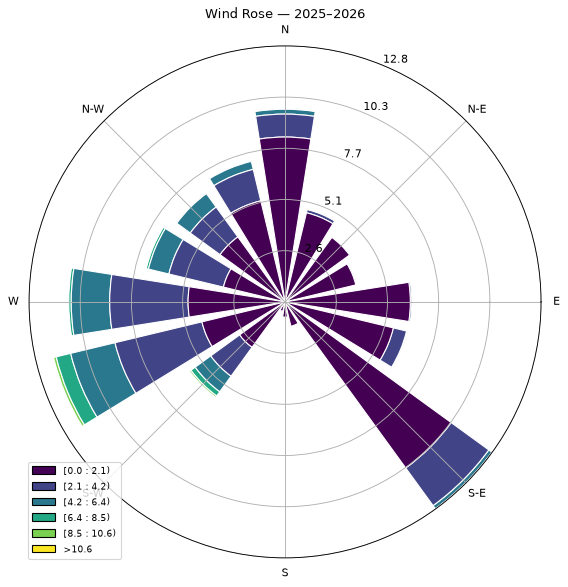

In [14]:
ax = windrose.WindroseAxes.from_ax()

ax.bar(
    clean_wind_data["W Direction(Deg)"],
    clean_wind_data["Spd(Km/hr)"],
    normed=True,
    opening=0.8,
    edgecolor="white"
)

ax.set_title("Wind Rose — 2025–2026")
ax.set_legend()

plt.show()

In [15]:
clean_wind_data["Spd(m/s)"] = (
    clean_wind_data["Spd(Km/hr)"] / 3.6
)
clean_wind_data = clean_wind_data[
    clean_wind_data["Spd(m/s)"] >= 1.0
].copy()
print("Remaining observations:", len(clean_wind_data))
print("Minimum wind speed:", clean_wind_data["Spd(m/s)"].min())
print("Maximum wind speed:", clean_wind_data["Spd(m/s)"].max())

Remaining observations: 1880
Minimum wind speed: 1.0
Maximum wind speed: 2.944444444444444


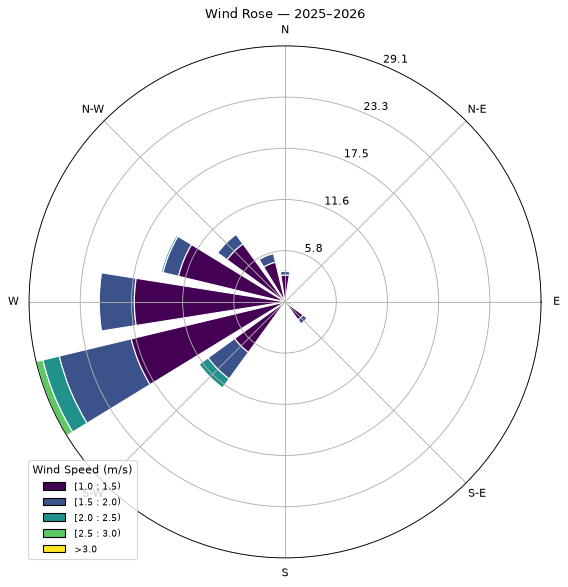

In [16]:
from windrose import WindroseAxes
import matplotlib.pyplot as plt

ax = WindroseAxes.from_ax()

ax.bar(
    clean_wind_data["W Direction(Deg)"],
    clean_wind_data["Spd(m/s)"],
    bins=[1, 1.5, 2, 2.5, 3],
    normed=True,
    opening=0.8,
    edgecolor="white"
)

ax.set_title("Wind Rose — 2025–2026")
ax.set_legend(title="Wind Speed (m/s)")

plt.show()